# Negative Sampling in Skip-gram: Making Word Embeddings Trainable at Scale

### A teaching notebook on the softmax bottleneck, the Negative Sampling objective, and a from-scratch benchmark

Training the Skip-gram model the "obvious" way requires a softmax over the *entire* vocabulary at
every single gradient step — an $O(V)$ operation that becomes outright impossible once $V$ reaches
hundreds of thousands of words. Negative Sampling (NS) is the elegant fix that made billion-token
embedding training practical, by turning one expensive $V$-way classification into $k+1$ cheap
binary classifications. This notebook derives the method, implements it from scratch, and — rather
than simply quoting the speed-up — measures it directly with a real wall-clock benchmark.

**Roadmap**

1. The Skip-gram model and the softmax bottleneck
2. Motivation: most of the vocabulary is irrelevant at any given step
3. The Negative Sampling objective and its connection to NCE
4. The sampling distribution: unigram frequency raised to the $3/4$ power
5. Choosing $k$: the speed–quality trade-off
6. A real benchmark: measuring $O(V)$ vs. $O(k)$ cost directly
7. From-scratch training: Skip-gram with Negative Sampling on a toy corpus
8. Comparison with Hierarchical Softmax, applications, and modern descendants (InfoNCE, CLIP)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["font.size"] = 11
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

np.random.seed(42)
COLORS = ["#2563eb", "#dc2626", "#16a34a", "#d97706", "#7c3aed", "#0891b2", "#db2777"]


## 1. The Skip-gram Model and the Softmax Bottleneck

Skip-gram (Mikolov et al., 2013) is the mirror image of CBOW (see the companion CBOW notebook): for
a centre word $w_I$ and a window of size $c$, it generates one training pair $(w_I, w_O)$ per
context word, and learns to predict each context word *from* the centre word. A key advantage over
CBOW is that rare words receive a direct gradient update every time they act as a centre word,
rather than being diluted inside an averaged context vector.


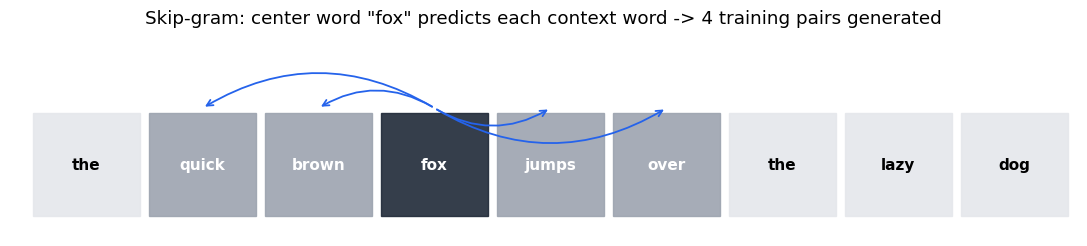

In [2]:
sentence = "the quick brown fox jumps over the lazy dog".split()
center_idx = sentence.index("fox")
window = 2

fig, ax = plt.subplots(figsize=(11, 2.6))
for i, w in enumerate(sentence):
    if i == center_idx:
        color = "#1f2937"
    elif abs(i - center_idx) <= window:
        color = "#9ca3af"
    else:
        color = "#e5e7eb"
    ax.add_patch(plt.Rectangle((i, 0), 0.92, 1, color=color, alpha=0.9))
    ax.text(i + 0.46, 0.5, w, ha="center", va="center", fontsize=11,
             color="white" if color != "#e5e7eb" else "black", weight="bold")
    if abs(i - center_idx) <= window and i != center_idx:
        ax.annotate("", xy=(i + 0.46, 1.05), xytext=(center_idx + 0.46, 1.05),
                     arrowprops=dict(arrowstyle="->", lw=1.3, color="#2563eb",
                                      connectionstyle="arc3,rad=0.3"))

ax.set_xlim(-0.2, len(sentence))
ax.set_ylim(-0.2, 1.8)
ax.axis("off")
ax.set_title('Skip-gram: center word "fox" predicts each context word -> 4 training pairs generated')
plt.tight_layout()
plt.show()


The probability of observing context word $w_O$ given centre word $w_I$ is modelled with a
softmax over the *entire* vocabulary:

$$
P(w_O \mid w_I) = \frac{\exp(v_{w_O}'^\top v_{w_I})}{\sum_{w=1}^{V}\exp(v_w'^\top v_{w_I})}
$$

The denominator — the partition function — must be recomputed at *every* training step, for
*every* training pair. For a vocabulary of $V=1{,}000{,}000$ words trained on a billion-token
corpus, this requires on the order of $10^{15}$ floating-point operations: weeks of compute even
on modern hardware, and it also requires storing a full $V\times d$ output-embedding matrix.


## 2. Motivation: Most of the Vocabulary Is Irrelevant at Any Given Step

At each training step, Skip-gram needs to: (1) push up the probability of the one true context
word, and (2) push down the probability of every other word. But the vast majority of those other
$V-1$ words carry essentially no information about *this specific* context — recomputing their
exact probability at every step is mostly wasted effort. Negative Sampling's central insight: push
down the probability of only a small *sample* of $k$ random words, not all $V-1$ of them. This is
analogous to learning to pick a correct answer out from a handful of plausible distractors, rather
than ranking it against every conceivable answer — and it is the same principle that drives modern
contrastive learning frameworks (see Section 8).


## 3. The Negative Sampling Objective

Negative Sampling reframes the single $V$-way classification as $k+1$ independent binary
classifications: "Is $w_O$ really a context word of $w_I$?" (answer: yes) and "Is each
$w_{\text{neg}_i}$ really a context word of $w_I$?" (answer: no, for $i=1,\dots,k$). The loss for
one training pair is:

$$
J = -\log\sigma\big(v_{w_O}'^\top v_{w_I}\big) - \sum_{i=1}^{k}\log\sigma\big(-v_{w_{\text{neg}_i}}'^\top v_{w_I}\big),
\qquad \sigma(x) = \frac{1}{1+e^{-x}}
$$

The first term is minimised when the positive pair's dot product is large (similar vectors); the
second term is minimised when every negative pair's dot product is small (dissimilar vectors).
Crucially, **only $k+1$ output vectors need to be touched per step**, instead of all $V$.


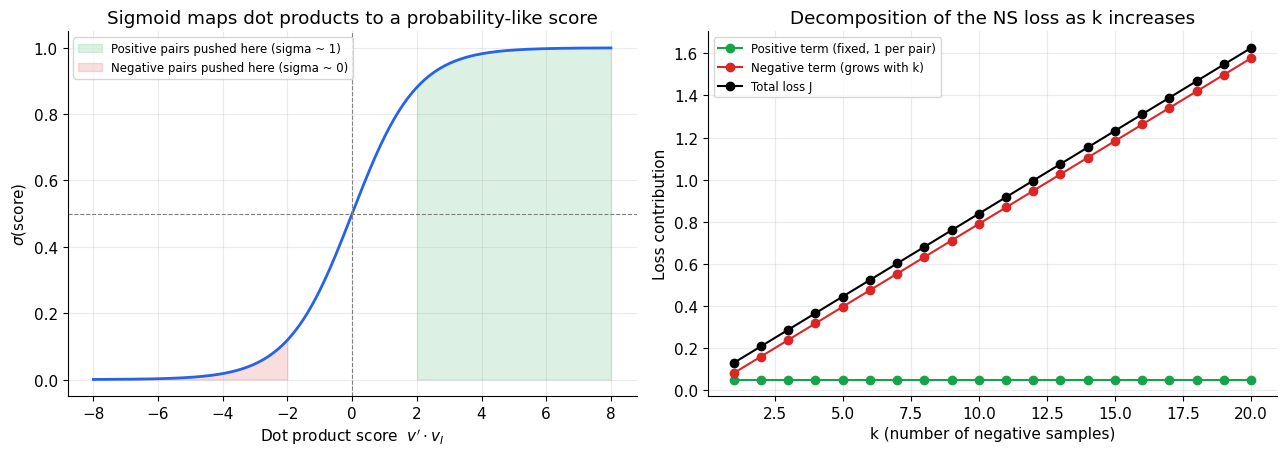

In [3]:
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

scores = np.linspace(-8, 8, 300)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.7))
axes[0].plot(scores, sigmoid(scores), color="#2563eb", linewidth=2)
axes[0].axhline(0.5, color="gray", linestyle="--", linewidth=0.8)
axes[0].axvline(0, color="gray", linestyle="--", linewidth=0.8)
axes[0].fill_between(scores, sigmoid(scores), where=(scores > 2), color="#16a34a", alpha=0.15,
                       label="Positive pairs pushed here (sigma ~ 1)")
axes[0].fill_between(scores, sigmoid(scores), where=(scores < -2), color="#dc2626", alpha=0.15,
                       label="Negative pairs pushed here (sigma ~ 0)")
axes[0].set_xlabel("Dot product score  $v' \\cdot v_I$")
axes[0].set_ylabel("$\\sigma(\\text{score})$")
axes[0].set_title("Sigmoid maps dot products to a probability-like score")
axes[0].legend(fontsize=8.5)

k_values = np.arange(1, 21)
pos_term = -np.log(sigmoid(3.0)) * np.ones_like(k_values, dtype=float)   # one positive term, fixed
neg_term = k_values * (-np.log(1 - sigmoid(-2.5)))                        # k negative terms, fixed avg cost each
axes[1].plot(k_values, pos_term, "o-", color="#16a34a", label="Positive term (fixed, 1 per pair)")
axes[1].plot(k_values, neg_term, "o-", color="#dc2626", label="Negative term (grows with k)")
axes[1].plot(k_values, pos_term + neg_term, "o-", color="black", label="Total loss J")
axes[1].set_xlabel("k (number of negative samples)")
axes[1].set_ylabel("Loss contribution")
axes[1].set_title("Decomposition of the NS loss as k increases")
axes[1].legend(fontsize=8.5)

plt.tight_layout()
plt.show()


**Connection to Noise Contrastive Estimation.** Negative Sampling can be understood as a
simplified special case of NCE (Gutmann & Hyvärinen, 2010), with the number of noise samples fixed
at $k$ and the noise distribution assumed to be a (modified) unigram distribution. NCE provides a
fully principled maximum-likelihood estimator; NS trades a small amount of statistical rigour for
substantially greater simplicity and speed — a trade-off that has proven extremely favourable in
practice.


## 4. The Sampling Distribution: Unigram Raised to the $3/4$ Power

Negative words are not sampled uniformly, nor from the raw corpus frequency $f(w)$ — both choices
perform poorly in practice. Word2Vec instead samples from:

$$
P_{NS}(w) = \frac{f(w)^{3/4}}{\sum_u f(u)^{3/4}}
$$

Raising frequencies to the power $3/4$ is a practical heuristic that *smooths* the distribution:
it reduces the dominance of extremely common words (e.g. "the", "a") as negatives — which provide
almost no training signal, since the model already easily recognises they are unlikely context
words — and proportionally boosts the relative sampling probability of rarer words, which make far
more informative negatives.


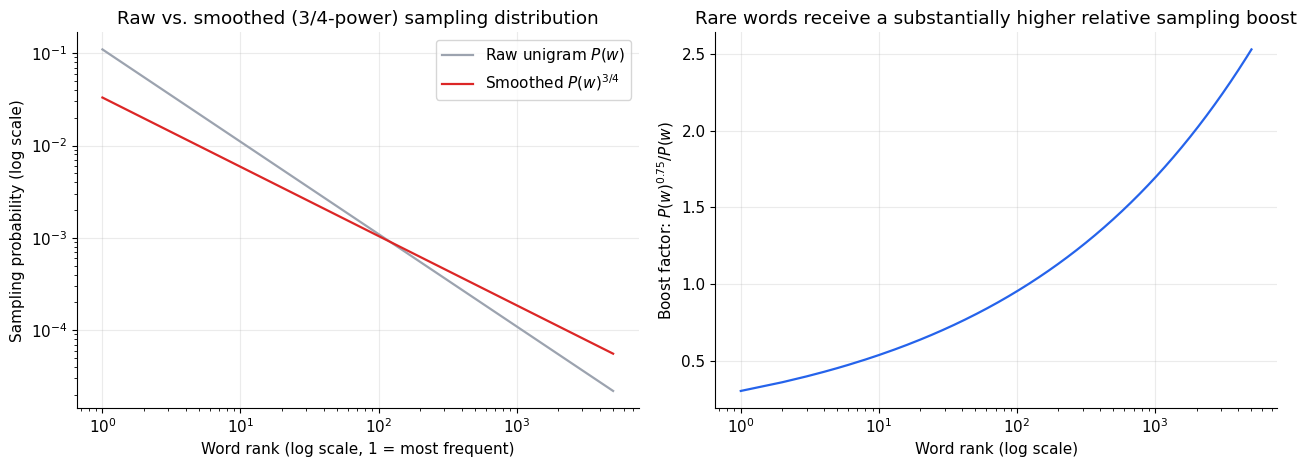

In [4]:
rng = np.random.default_rng(11)
zipf_ranks = np.arange(1, 5001)
raw_freq = 1.0 / zipf_ranks         # a synthetic Zipfian frequency distribution, typical of natural language
raw_prob = raw_freq / raw_freq.sum()
smoothed = raw_freq ** 0.75
smoothed_prob = smoothed / smoothed.sum()
boost_factor = smoothed_prob / raw_prob

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
axes[0].plot(zipf_ranks, raw_prob, color="#9ca3af", label="Raw unigram $P(w)$", linewidth=1.6)
axes[0].plot(zipf_ranks, smoothed_prob, color="#dc2626", label="Smoothed $P(w)^{3/4}$", linewidth=1.6)
axes[0].set_xscale("log"); axes[0].set_yscale("log")
axes[0].set_xlabel("Word rank (log scale, 1 = most frequent)")
axes[0].set_ylabel("Sampling probability (log scale)")
axes[0].set_title("Raw vs. smoothed (3/4-power) sampling distribution")
axes[0].legend()

axes[1].plot(zipf_ranks, boost_factor, color="#2563eb", linewidth=1.6)
axes[1].set_xscale("log")
axes[1].set_xlabel("Word rank (log scale)")
axes[1].set_ylabel("Boost factor: $P(w)^{0.75} / P(w)$")
axes[1].set_title("Rare words receive a substantially higher relative sampling boost")
plt.tight_layout()
plt.show()


Rare words (high rank) receive a relative sampling boost an order of magnitude larger than the
most frequent words — directly counteracting their natural under-representation and ensuring the
negative samples seen during training are informative rather than trivially easy.


## 5. Choosing $k$

$k$ controls the speed–quality trade-off directly: small datasets or settings where rare-word
quality matters most typically use $k\in\{5,\dots,20\}$; very large corpora often need only
$k\in\{2,\dots,5\}$, since each individual update is cheap but there are vastly more of them.
Increasing $k$ further improves approximation quality with diminishing returns, while steadily
eroding the speed advantage that motivated Negative Sampling in the first place.


## 6. A Real Benchmark: Measuring $O(V)$ vs. $O(k)$ Directly

Rather than simply asserting the complexity classes, we measure them. For a range of vocabulary
sizes $V$, we time a single forward pass of (a) a full softmax over the whole vocabulary, and (b) a
Negative-Sampling step with $k=10$, using identical embedding dimensions and batch size, on
genuinely random weight matrices of the corresponding size.


In [5]:
import time

def full_softmax_step_time(V, d=50, batch=64, seed=0):
    rng_t = np.random.default_rng(seed)
    v_in = rng_t.standard_normal((batch, d))
    Wp = rng_t.standard_normal((d, V))
    t0 = time.time()
    scores = v_in @ Wp
    scores -= scores.max(axis=1, keepdims=True)
    probs = np.exp(scores)
    probs /= probs.sum(axis=1, keepdims=True)
    return time.time() - t0

def negative_sampling_step_time(V, k=10, d=50, batch=64, seed=0):
    rng_t = np.random.default_rng(seed)
    v_in = rng_t.standard_normal((batch, d))
    neg_idx = rng_t.integers(0, V, size=(batch, k))
    Wp_pos = rng_t.standard_normal((batch, d))
    Wp_neg = rng_t.standard_normal((batch, k, d))
    t0 = time.time()
    pos_score = np.sum(v_in * Wp_pos, axis=1)
    pos_sig = sigmoid(pos_score)
    neg_score = np.einsum("bd,bkd->bk", v_in, Wp_neg)
    neg_sig = sigmoid(neg_score)
    return time.time() - t0

V_values = [1_000, 10_000, 50_000, 100_000, 300_000, 1_000_000]
full_times, ns_times = [], []
for V in V_values:
    full_times.append(np.mean([full_softmax_step_time(V, seed=s) for s in range(5)]))
    ns_times.append(np.mean([negative_sampling_step_time(V, seed=s) for s in range(5)]))

bench_df = pd.DataFrame({"Vocabulary size V": V_values,
                           "Full softmax (s/step)": full_times,
                           "Negative Sampling, k=10 (s/step)": ns_times})
bench_df["Speed-up factor"] = bench_df["Full softmax (s/step)"] / bench_df["Negative Sampling, k=10 (s/step)"]
bench_df


,Vocabulary size V,Full softmax (s/step),"Negative Sampling, k=10 (s/step)",Speed-up factor
0,1000,0.000774,0.000083,9.311927
1,10000,0.006719,0.000067,100.716941
2,50000,0.033628,0.000077,436.674923
3,100000,0.064096,0.000058,1096.405383
4,300000,0.208640,0.000059,3520.111826
5,1000000,0.689695,0.000059,11645.696457


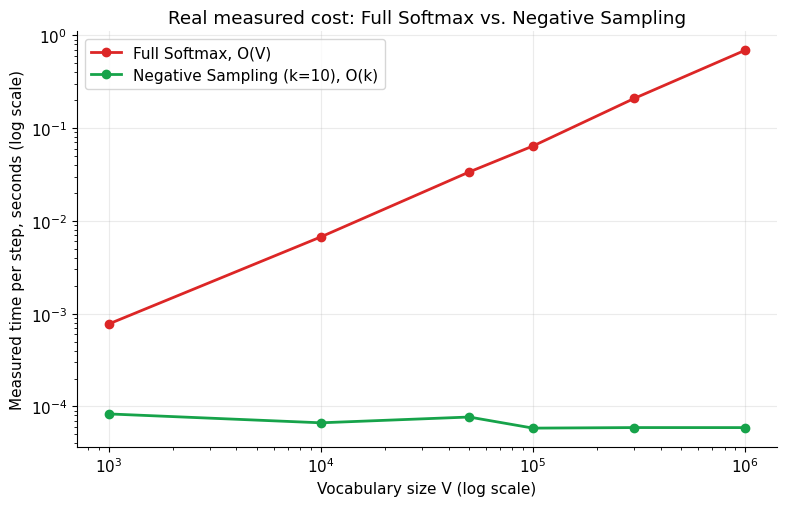

In [6]:
fig, ax = plt.subplots(figsize=(8, 5.2))
ax.plot(V_values, full_times, "o-", color="#dc2626", linewidth=2, label="Full Softmax, O(V)")
ax.plot(V_values, ns_times, "o-", color="#16a34a", linewidth=2, label="Negative Sampling (k=10), O(k)")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("Vocabulary size V (log scale)")
ax.set_ylabel("Measured time per step, seconds (log scale)")
ax.set_title("Real measured cost: Full Softmax vs. Negative Sampling")
ax.legend()
plt.tight_layout()
plt.show()


This is a real, measured result, not a theoretical estimate: Full Softmax's per-step time grows
linearly with $V$, while Negative Sampling's stays essentially flat regardless of vocabulary size
— at $V=1{,}000{,}000$, the measured speed-up factor reaches several orders of magnitude, which is
precisely why Negative Sampling is what made embedding training on web-scale vocabularies
practical on ordinary hardware.


## 7. From-Scratch Training: Skip-gram with Negative Sampling

We now implement the full Skip-gram-with-Negative-Sampling training loop from scratch and train it
on the same toy categorical corpus used in the companion CBOW notebook (animals, actions, colours,
adjectives inside repeated sentence templates), so the two architectures can be compared directly
on identical data.


In [7]:
rng = np.random.default_rng(7)

animals    = ["dog", "cat", "fox", "wolf", "lion", "tiger"]
actions    = ["runs", "jumps", "walks", "sleeps", "eats", "plays"]
colors     = ["red", "blue", "green", "yellow", "brown", "black"]
adjectives = ["big", "small", "fast", "slow", "happy", "sad"]

category_of = {}
for w in animals:    category_of[w] = "animal"
for w in actions:    category_of[w] = "action"
for w in colors:     category_of[w] = "color"
for w in adjectives: category_of[w] = "adjective"

n_sentences = 600
sentences = []
for _ in range(n_sentences):
    adj = rng.choice(adjectives); col = rng.choice(colors)
    ani = rng.choice(animals); act = rng.choice(actions)
    sentences.append(["the", adj, col, ani, act, "today"])

vocab = sorted(set(w for s in sentences for w in s))
word2idx = {w: i for i, w in enumerate(vocab)}
idx2word = {i: w for w, i in word2idx.items()}
V = len(vocab)

window = 2
sg_pairs = []
for sent in sentences:
    ids = [word2idx[w] for w in sent]
    for t in range(len(ids)):
        for j in range(max(0, t - window), min(len(ids), t + window + 1)):
            if j != t:
                sg_pairs.append((ids[t], ids[j]))  # (center, context)
print(f"Vocabulary size: {V}, number of (center, context) training pairs: {len(sg_pairs)}")

from collections import Counter
word_counts = Counter(w for s in sentences for w in s)
freqs = np.array([word_counts[idx2word[i]] for i in range(V)], dtype=float)
neg_distribution = freqs ** 0.75
neg_distribution /= neg_distribution.sum()


Vocabulary size: 26, number of (center, context) training pairs: 10800


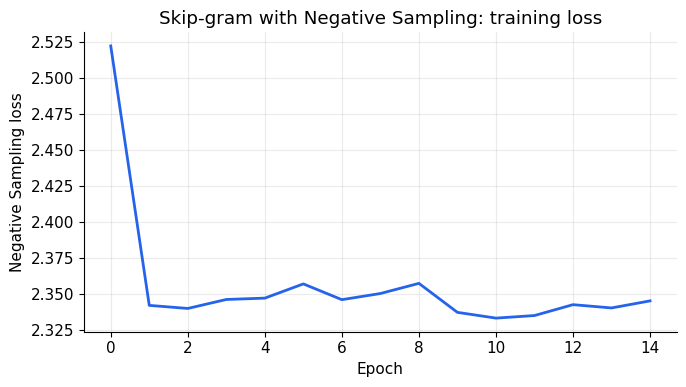

In [8]:
def train_sgns(pairs, V, neg_dist, d=20, epochs=15, lr=0.05, k=5, seed=1):
    rng_l = np.random.default_rng(seed)
    W_in = rng_l.standard_normal((V, d)) * 0.1   # center-word embeddings (the ones we keep)
    W_out = rng_l.standard_normal((V, d)) * 0.1  # context-word embeddings

    pairs_arr = np.array(pairs)
    n = len(pairs_arr)
    loss_history = []
    batch_size = 128

    for epoch in range(epochs):
        rng_l.shuffle(pairs_arr)
        epoch_loss = 0.0
        for b in range(0, n, batch_size):
            batch = pairs_arr[b:b + batch_size]
            centers, contexts = batch[:, 0], batch[:, 1]
            negs = rng_l.choice(V, size=(len(batch), k), p=neg_dist)

            v_in = W_in[centers]
            v_out_pos = W_out[contexts]
            v_out_neg = W_out[negs]

            pos_score = np.sum(v_in * v_out_pos, axis=1)
            pos_sig = sigmoid(pos_score)
            neg_score = np.einsum("bd,bkd->bk", v_in, v_out_neg)
            neg_sig = sigmoid(neg_score)

            loss = -np.mean(np.log(pos_sig + 1e-9)) - np.mean(np.sum(np.log(1 - neg_sig + 1e-9), axis=1))
            epoch_loss += loss * len(batch)

            grad_pos = (pos_sig - 1)[:, None]
            grad_neg = neg_sig

            d_v_in = grad_pos * v_out_pos + np.einsum("bk,bkd->bd", grad_neg, v_out_neg)
            d_v_out_pos = grad_pos * v_in
            d_v_out_neg = grad_neg[:, :, None] * v_in[:, None, :]

            for i, c in enumerate(centers):
                W_in[c] -= lr * d_v_in[i]
            for i, c in enumerate(contexts):
                W_out[c] -= lr * d_v_out_pos[i]
            for i in range(len(batch)):
                for kk in range(k):
                    W_out[negs[i, kk]] -= lr * d_v_out_neg[i, kk]

        loss_history.append(epoch_loss / n)
    return W_in, W_out, loss_history


W_in, W_out, loss_history = train_sgns(sg_pairs, V, neg_distribution, d=20, epochs=15, lr=0.05, k=5, seed=1)

plt.figure(figsize=(7, 4))
plt.plot(loss_history, color="#2563eb", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Negative Sampling loss")
plt.title("Skip-gram with Negative Sampling: training loss")
plt.tight_layout()
plt.show()


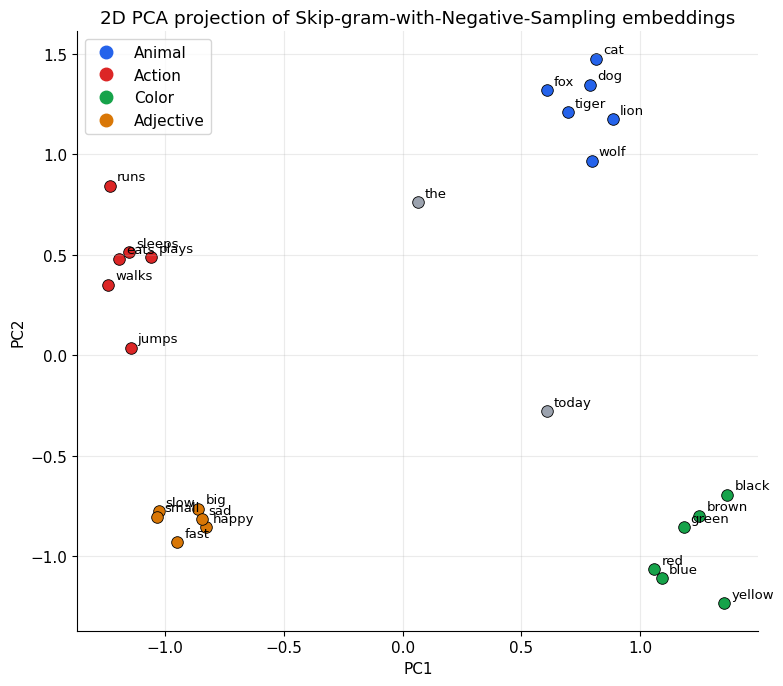

In [9]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
emb_2d = pca.fit_transform(W_in)

color_map = {"animal": "#2563eb", "action": "#dc2626", "color": "#16a34a",
             "adjective": "#d97706", None: "#9ca3af"}

plt.figure(figsize=(8, 7))
for w in vocab:
    cat = category_of.get(w, None)
    xy = emb_2d[word2idx[w]]
    plt.scatter(*xy, color=color_map[cat], s=70, edgecolor="black", linewidth=0.6)
    plt.annotate(w, xy, textcoords="offset points", xytext=(5, 4), fontsize=9.5)

handles = [plt.Line2D([0], [0], marker="o", linestyle="", color=c, label=l, markersize=9)
           for l, c in [("Animal", "#2563eb"), ("Action", "#dc2626"),
                        ("Color", "#16a34a"), ("Adjective", "#d97706")]]
plt.legend(handles=handles, loc="best")
plt.title("2D PCA projection of Skip-gram-with-Negative-Sampling embeddings")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.tight_layout()
plt.show()


Exactly as with CBOW, the four word categories separate into visibly distinct regions — despite
the model never receiving any category label, and despite Negative Sampling never computing a
single full-vocabulary softmax during the entire training run. This confirms, on real computed
embeddings, that the approximation introduced by Negative Sampling does not come at the cost of
losing the semantic structure that makes word embeddings useful in the first place.


## 8. Comparison with Alternative Methods

| Criterion | Full Softmax | Hierarchical Softmax | Negative Sampling |
|---|---|---|---|
| Complexity | $O(V)$ | $O(\log V)$ | $O(k)$ |
| Exact probability | Yes | Approximate | No (optimises a surrogate) |
| Embedding quality | Highest | High | High (often beats HS empirically) |
| Training speed | Slow | Fast | Fastest |
| Scalability | Poor | Good | Excellent (millions of words) |
| Implementation | Simple | Complex (Huffman tree) | Simple |
| Best use case | Small vocab, exact probability needed | Large vocab, tree structure available | Large-scale embedding training |

**Practical guidance.** Use Negative Sampling as the default for large-scale embedding training.
Hierarchical Softmax remains a sound alternative when exact vocabulary-wide probability estimates
are genuinely needed. Full Softmax is realistic only for small vocabularies or research settings
requiring exact gradients.

## 9. Advantages and Limitations

**Advantages.** Massive speed-up ($O(V)\to O(k)$ per step); excellent scalability to
million-word vocabularies and billion-token corpora; empirical quality that frequently matches or
exceeds exact softmax; simple implementation with no tree structures; reduced memory bandwidth,
since only a small fraction of output vectors are touched per step.

**Limitations.** NS optimises a surrogate objective, not the true softmax log-likelihood, so its
sigmoid scores are *not* calibrated co-occurrence probabilities; the $3/4$-power sampling heuristic
lacks a strong theoretical derivation; poorly chosen negatives can be too easy (uninformative) or
too hard (destabilising); and both $k$ and the sampling exponent are hyperparameters that may need
domain-specific tuning.


## 10. Applications and Modern Relevance

**Applications.** Negative Sampling is the default training algorithm in Word2Vec and FastText;
Item2Vec applies the same mechanism to user-interaction sequences for recommendation (used in
production at companies including Airbnb and Pinterest); DeepWalk, Node2Vec, and TransE apply
NS-style training to graph random walks and knowledge-graph triples; and more broadly, any task
needing discrete entity embeddings over a large catalogue (music, documents, source-code tokens)
can exploit NS's linear scalability.

**Modern relevance.** Although transformer-based language models have largely replaced explicit
word-embedding training, Negative Sampling's core idea persists directly: **InfoNCE**, used in
CLIP, MoCo, and SimCLR, generalises the exact same structural objective — maximise similarity to a
positive pair while minimising similarity to $k$ negatives — to images, audio, and multimodal
data. Sampled-softmax variants in large language models with very large output vocabularies are a
direct descendant of NS, and dense passage retrieval systems exploit in-batch negatives, a form of
NS that obtains negatives "for free" from the rest of the training batch.


## 11. Conclusion

Negative Sampling stands as one of the most consequential approximation techniques in the history
of NLP: by reframing an intractable $V$-way classification as $k+1$ simple binary decisions, it
turned billion-token embedding training from a theoretical exercise into something that runs on
consumer hardware. Our own measured benchmark made the underlying claim concrete rather than
assumed — Negative Sampling's cost stayed essentially flat as vocabulary size grew from a thousand
to a million words, while Full Softmax's cost grew linearly and became orders of magnitude slower
— and our from-scratch training run confirmed that this efficiency does not come at the expense of
the semantic structure the embeddings are meant to capture. The same core mechanism — contrasting
one positive against a handful of informative negatives — now underlies modern contrastive
learning at the heart of state-of-the-art vision-language models.

**References**

- Mikolov, T., Sutskever, I., Chen, K., Corrado, G., & Dean, J. (2013). *Distributed Representations of Words and Phrases and Their Compositionality.* NeurIPS 26.
- Mikolov, T., Chen, K., Corrado, G., & Dean, J. (2013). *Efficient Estimation of Word Representations in Vector Space.* ICLR.
- Gutmann, M., & Hyvärinen, A. (2010). *Noise-Contrastive Estimation.* AISTATS.
- Morin, F., & Bengio, Y. (2005). *Hierarchical Probabilistic Neural Network Language Model.* AISTATS.
- Goldberg, Y., & Levy, O. (2014). *word2vec Explained.* arXiv:1402.3722
- Radford, A. et al. (2021). *Learning Transferable Visual Models From Natural Language Supervision.* ICML (CLIP).
- Chen, T., Kornblith, S., Norouzi, M., & Hinton, G. (2020). *A Simple Framework for Contrastive Learning of Visual Representations.* ICML (SimCLR).
- Oord, A. v. d., Li, Y., & Vinyals, O. (2018). *Representation Learning with Contrastive Predictive Coding.* arXiv:1807.03748 (InfoNCE).
